In [2]:
import os
import pickle
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def load_embeddings(user_path, candidate_path):
    with open(user_path, 'rb') as f:
        user_embeddings = pickle.load(f)
    
    with open(candidate_path, 'rb') as f:
        candidate_embeddings_dict = pickle.load(f)
    
    candidate_ids, candidate_embeddings = zip(*candidate_embeddings_dict.items())
    candidate_embeddings = torch.tensor(np.array(candidate_embeddings))
    
    return user_embeddings, candidate_embeddings

def sample_users(user_embeddings, sample_size=10000):
    if len(user_embeddings) > sample_size:
        sampled_indices = np.random.choice(len(user_embeddings), sample_size, replace=False)
        user_embeddings_sample = user_embeddings[sampled_indices]
    else:
        user_embeddings_sample = user_embeddings
    return user_embeddings_sample

def sample_candidates(candidate_embeddings, sample_size=3500):
    if len(candidate_embeddings) > sample_size:
        sampled_indices = np.random.choice(len(candidate_embeddings), sample_size, replace=False)
        candidate_embeddings_sample = candidate_embeddings[sampled_indices]
    else:
        candidate_embeddings_sample = candidate_embeddings
    return candidate_embeddings_sample

def adjust_embedding_dimensions(user_embeddings, candidate_embeddings):
    user_interest_dim = user_embeddings.shape[1]  # num_interest for users
    candidate_interest_dim = candidate_embeddings.shape[1]  # num_interest for candidates

    if user_interest_dim != candidate_interest_dim:
        if candidate_interest_dim < user_interest_dim:
            # Repeat candidate embeddings along the interest dimension
            candidate_embeddings = candidate_embeddings.repeat(1, user_interest_dim, 1)
        else:
            # Truncate candidate embeddings to match user embeddings' interest dimension
            candidate_embeddings = candidate_embeddings[:, :user_interest_dim, :]
    
    return candidate_embeddings

def calculate_scores(user_embeddings, candidate_embeddings, scoring_fn, batch_size=64):
    user_embeddings = torch.tensor(user_embeddings)
    candidate_embeddings = candidate_embeddings

    num_users = user_embeddings.size(0)
    num_candidates = candidate_embeddings.size(0)
    
    scores = torch.empty((num_users, num_candidates))

    for i in range(0, num_users, batch_size):
        user_batch = user_embeddings[i:i+batch_size]
        user_batch_expanded = user_batch.unsqueeze(1).expand(-1, num_candidates, -1, -1)
        candidate_embeddings_expanded = candidate_embeddings.squeeze(1).expand(user_batch.size(0), num_candidates, -1, -1)

        batch_scores = scoring_fn(user_batch_expanded, candidate_embeddings_expanded, dim=-1).mean(dim=-1)
        scores[i:i+batch_size] = batch_scores

    # Apply sigmoid to make scores positive
    scores = torch.sigmoid(scores)

    return scores

def analyze_scores(scores):
    mean_scores_per_user = scores.mean(axis=1)
    mean_scores_per_candidate = scores.mean(axis=0)
    std_scores_per_candidate = scores.std(axis=0)

    return mean_scores_per_user, mean_scores_per_candidate, std_scores_per_candidate


In [2]:

def calculate_overall_stats(mean_scores):
    """
    Calculate overall mean and standard deviation for the given scores.

    Args:
        mean_scores: Array of mean scores.

    Returns:
        overall_mean: Mean of the mean scores.
        overall_std: Standard deviation of the mean scores.
    """
    overall_mean = np.mean(mean_scores)
    overall_std = np.std(mean_scores)
    
    return overall_mean, overall_std

def compare_disentanglement(mean_scores_1, mean_scores_2):
    """
    Compare the overall statistics between two configurations to evaluate improvement due to disentanglement.

    Args:
        mean_scores_1: Mean scores for the first configuration (Without Disentanglement).
        mean_scores_2: Mean scores for the second configuration (With Disentanglement).

    Returns:
        A dictionary containing the comparison results.
    """
    overall_mean_1, overall_std_1 = calculate_overall_stats(mean_scores_1)
    overall_mean_2, overall_std_2 = calculate_overall_stats(mean_scores_2)
    
    improvement_in_mean = overall_mean_2 - overall_mean_1
    
    comparison_results = {
        "Without Disentanglement": {
            "Mean": overall_mean_1,
            "Standard Deviation": overall_std_1,
        },
        "With Disentanglement": {
            "Mean": overall_mean_2,
            "Standard Deviation": overall_std_2,
        },
        "Improvement in Mean": improvement_in_mean,
    }
    
    return comparison_results

def plot_side_by_side_scores(mean_scores_1, std_scores_1, mean_scores_2, std_scores_2, N, save_dir, label1='Without Disentanglement', label2='With Disentanglement'):
    """
    Plots the scores side by side for comparison with synchronized Y-axes for each configuration.

    Args:
        mean_scores_1: Mean scores for the first configuration.
        std_scores_1: Standard deviation of scores for the first configuration.
        mean_scores_2: Mean scores for the second configuration.
        std_scores_2: Standard deviation of scores for the second configuration.
        N: Value of N being used.
        save_dir: Directory to save the plot.
        label1: Label for the first configuration (default is 'Without Disentanglement').
        label2: Label for the second configuration (default is 'With Disentanglement').
    """
    os.makedirs(save_dir, exist_ok=True)
    
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Ensure inputs are NumPy arrays
    mean_scores_1 = np.array(mean_scores_1)
    std_scores_1 = np.array(std_scores_1)
    mean_scores_2 = np.array(mean_scores_2)
    std_scores_2 = np.array(std_scores_2)

    # Calculate overall statistics
    overall_mean_1, overall_std_1 = calculate_overall_stats(mean_scores_1)
    overall_mean_2, overall_std_2 = calculate_overall_stats(mean_scores_2)

    # Plot the first configuration (Without Disentanglement) - Blue
    sorted_indices_1 = np.argsort(mean_scores_1)
    sorted_mean_scores_1 = mean_scores_1[sorted_indices_1]
    sorted_std_scores_1 = std_scores_1[sorted_indices_1]

    line1, = ax1.plot(sorted_mean_scores_1, label=f'{label1} Mean', color='blue')
    fill1 = ax1.fill_between(range(len(sorted_mean_scores_1)), sorted_mean_scores_1 - sorted_std_scores_1, sorted_mean_scores_1 + sorted_std_scores_1, alpha=0.2, color='blue', label=f'{label1} Std Dev')
    ax1.set_xlabel('News sorted by their mean recommendation score')
    ax1.set_ylabel('Recommendation score (Without Disentanglement)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Plot the second configuration (With Disentanglement) - Orange on the same plot but different Y-axis
    ax2 = ax1.twinx()
    sorted_indices_2 = np.argsort(mean_scores_2)
    sorted_mean_scores_2 = mean_scores_2[sorted_indices_2]
    sorted_std_scores_2 = std_scores_2[sorted_indices_2]

    line2, = ax2.plot(sorted_mean_scores_2, label=f'{label2} Mean', color='orange')
    fill2 = ax2.fill_between(range(len(sorted_mean_scores_2)), sorted_mean_scores_2 - sorted_std_scores_2, sorted_mean_scores_2 + sorted_std_scores_2, alpha=0.2, color='orange', label=f'{label2} Std Dev')
    ax2.set_ylabel('Recommendation score (With Disentanglement)', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

    # Find the global min and max with type checking
    if len(sorted_mean_scores_1) > 0 and len(sorted_mean_scores_2) > 0:
        combined_min = min(np.min(sorted_mean_scores_1), np.min(sorted_mean_scores_2))
        combined_max = max(np.max(sorted_mean_scores_1), np.max(sorted_mean_scores_2))
    else:
        raise ValueError("One of the score arrays is empty, unable to determine min/max values.")

    # Round the min and max to the nearest 0.01 or 0.02 for consistent scaling
    combined_min = np.floor(combined_min * 100) / 100
    combined_max = np.ceil(combined_max * 100) / 100

    # Apply the same Y-axis limits and ticks to both axes
    ax1.set_ylim([combined_min, combined_max])
    ax2.set_ylim([combined_min, combined_max])

    # Generate identical ticks for both axes
    ticks = np.arange(combined_min, combined_max + 0.01, 0.01)  # Adjust step size if necessary
    ax1.set_yticks(ticks)
    ax2.set_yticks(ticks)

    # Create a single legend for both axes
    lines = [line1, line2]
    fills = [fill1, fill2]
    ax1.legend(lines + fills, [l.get_label() for l in lines + fills], loc='upper center')

    # Annotate the graph with overall statistics
    ax1.text(0.95, 0.05, f'{label1}\nMean: {overall_mean_1:.4f}\nStd Dev: {overall_std_1:.4f}',
             transform=ax1.transAxes, fontsize=10, verticalalignment='bottom', horizontalalignment='right', color='blue', bbox=dict(facecolor='white', alpha=0.5))
    ax2.text(0.95, 0.95, f'{label2}\nMean: {overall_mean_2:.4f}\nStd Dev: {overall_std_2:.4f}',
             transform=ax2.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', color='orange', bbox=dict(facecolor='white', alpha=0.5))

    plt.title(f'Comparison of Recommendation Scores for N={N}')
    fig.tight_layout()

    save_path = os.path.join(save_dir, f'side_by_side_scores_N{N}.png')
    plt.savefig(save_path)
    plt.show()
    plt.close()
    print(f'Saved side-by-side comparison plot at {save_path}')
    
    # Compare and print results
    comparison_results = compare_disentanglement(mean_scores_1, mean_scores_2)
    print("Comparison Results:")
    for key, value in comparison_results.items():
        print(f"{key}: {value}")
    
    return save_path


def process_embeddings_and_plot_side_by_side(N, user_path_1, user_path_2, candidate_path, save_dir, scoring_fn=torch.nn.functional.cosine_similarity):
    """
    Processes embeddings for two configurations and plots side by side.

    Args:
        N: The value of N being used.
        user_path_1: Path to the user embeddings for the first configuration.
        user_path_2: Path to the user embeddings for the second configuration.
        candidate_path: Path to the candidate embeddings.
        save_dir: Directory to save the plots.
        scoring_fn: Function to compute scores (default is cosine similarity).
    """
    # Process the first configuration
    print(f'Processing {user_path_1} (Without Disentanglement)')
    user_embeddings_1, candidate_embeddings_1 = load_embeddings(user_path_1, candidate_path)
    candidate_embeddings_1 = adjust_embedding_dimensions(user_embeddings_1, candidate_embeddings_1)
    user_embeddings_sample_1 = sample_users(user_embeddings_1)
    candidate_embeddings_sample_1 = sample_candidates(candidate_embeddings_1)
    scores_1 = calculate_scores(user_embeddings_sample_1, candidate_embeddings_sample_1, scoring_fn)
    mean_scores_per_user_1, mean_scores_per_candidate_1, std_scores_per_candidate_1 = analyze_scores(scores_1)

    # Process the second configuration
    print(f'Processing {user_path_2} (With Disentanglement)')
    user_embeddings_2, candidate_embeddings_2 = load_embeddings(user_path_2, candidate_path)
    candidate_embeddings_2 = adjust_embedding_dimensions(user_embeddings_2, candidate_embeddings_2)
    user_embeddings_sample_2 = sample_users(user_embeddings_2)
    candidate_embeddings_sample_2 = sample_candidates(candidate_embeddings_2)
    scores_2 = calculate_scores(user_embeddings_sample_2, candidate_embeddings_sample_2, scoring_fn)
    mean_scores_per_user_2, mean_scores_per_candidate_2, std_scores_per_candidate_2 = analyze_scores(scores_2)

    # Plot side by side
    return plot_side_by_side_scores(mean_scores_per_candidate_1, std_scores_per_candidate_1, mean_scores_per_candidate_2, std_scores_per_candidate_2, N, save_dir)

# Define the candidate path and save directory
candidate_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/dev_candidate_embeddings.pkl'
save_dir = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/mean&variance_sigmoid'


Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl (Without Disentanglement)
Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_dis_cos_bce_lamda_s_0.9/user_representations.pkl (With Disentanglement)


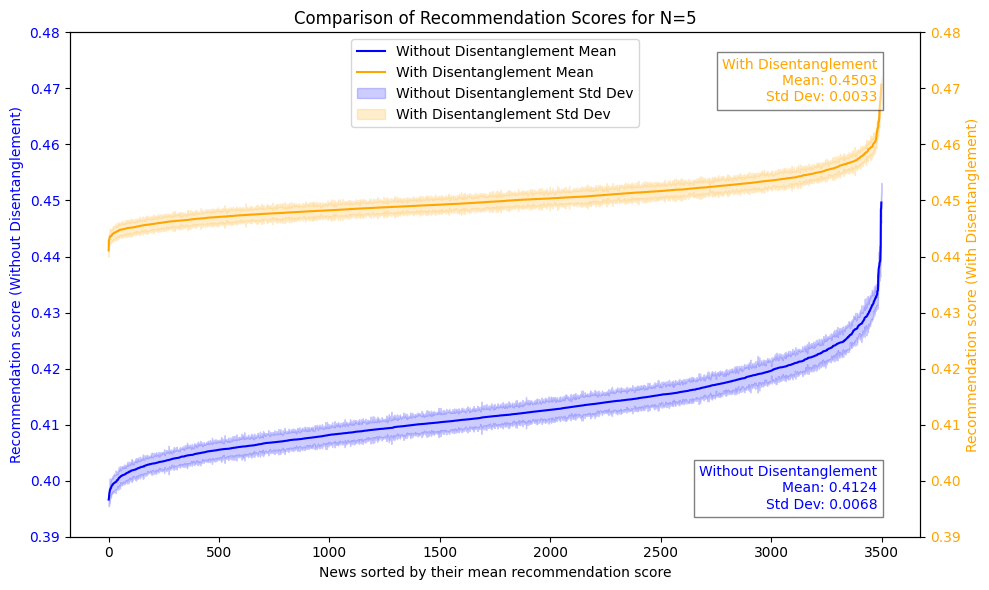

Saved side-by-side comparison plot at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/mean&variance_sigmoid/side_by_side_scores_N5.png
Comparison Results:
Without Disentanglement: {'Mean': 0.41236272, 'Standard Deviation': 0.006845946}
With Disentanglement: {'Mean': 0.45026973, 'Standard Deviation': 0.0033294156}
Improvement in Mean: 0.03790700435638428


'/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/mean&variance_sigmoid/side_by_side_scores_N5.png'

In [3]:

# Process and plot for N=5
process_embeddings_and_plot_side_by_side(
    N=5,
    user_path_1='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl',
    user_path_2='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    candidate_path=candidate_path,
    save_dir=save_dir
)

Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl (Without Disentanglement)


Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_dis_cos_bce_lamda_s_0.9_user_representations/user_representations.pkl (With Disentanglement)


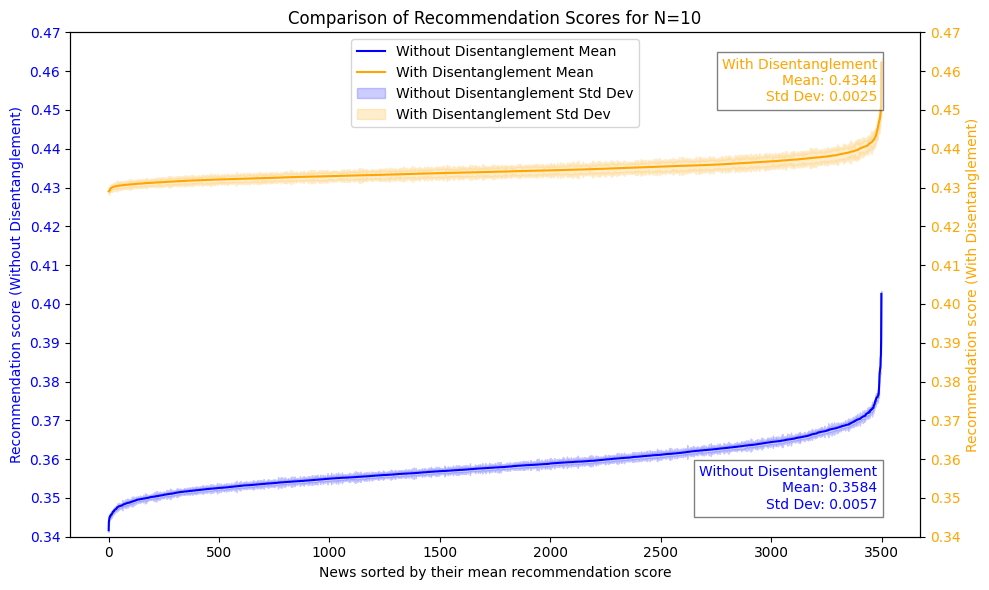

Saved side-by-side comparison plot at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/mean&variance_sigmoid/side_by_side_scores_N10.png
Comparison Results:
Without Disentanglement: {'Mean': 0.3583927, 'Standard Deviation': 0.0057416223}
With Disentanglement: {'Mean': 0.43441275, 'Standard Deviation': 0.002501357}
Improvement in Mean: 0.07602006196975708


'/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/mean&variance_sigmoid/side_by_side_scores_N10.png'

In [4]:
# Process and plot for N=10
process_embeddings_and_plot_side_by_side(
    N=10,
    user_path_1='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl',
    user_path_2='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_dis_cos_bce_lamda_s_0.9_user_representations/user_representations.pkl',
    candidate_path=candidate_path,
    save_dir=save_dir
)

Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl (Without Disentanglement)
Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_dis_cos_bce_lamda_s_0.9/user_representations.pkl (With Disentanglement)


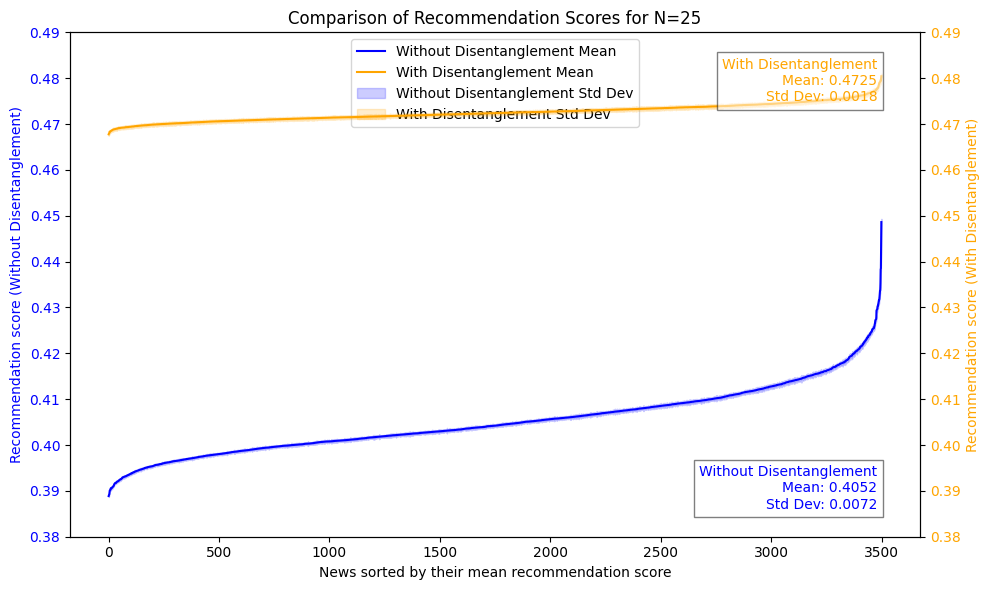

Saved side-by-side comparison plot at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/mean&variance_sigmoid/side_by_side_scores_N25.png
Comparison Results:
Without Disentanglement: {'Mean': 0.40519965, 'Standard Deviation': 0.0071832356}
With Disentanglement: {'Mean': 0.4724902, 'Standard Deviation': 0.0017897265}
Improvement in Mean: 0.0672905445098877


'/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/mean&variance_sigmoid/side_by_side_scores_N25.png'

In [5]:
# Process and plot for N=25
process_embeddings_and_plot_side_by_side(
    N=25,
    user_path_1='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl',
    user_path_2='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    candidate_path=candidate_path,
    save_dir=save_dir
)


Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl (Without Disentanglement)
Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_dis_cos_bce_lamda_s_0.90/user_representations.pkl (With Disentanglement)


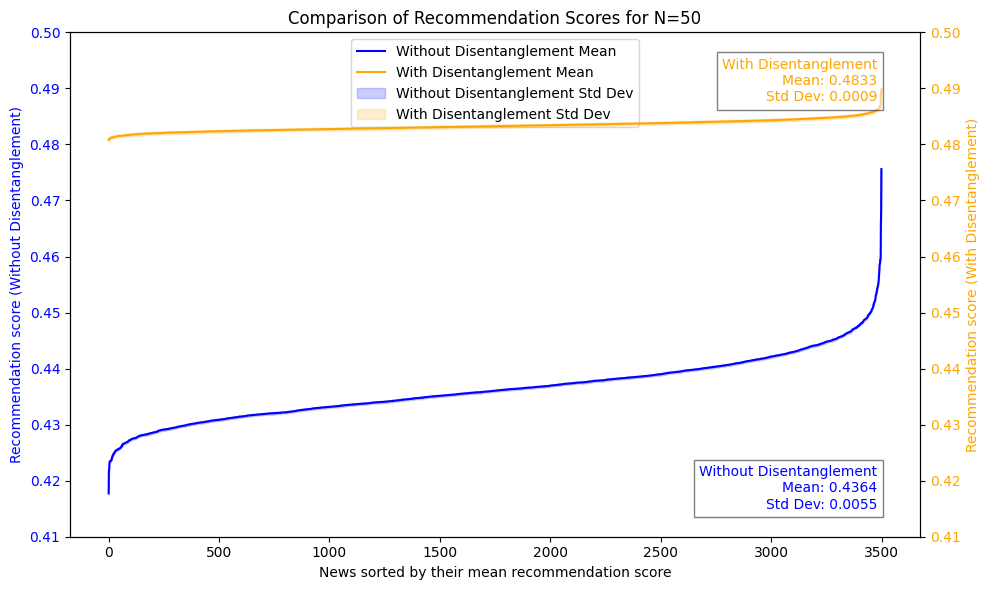

Saved side-by-side comparison plot at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/mean&variance_sigmoid/side_by_side_scores_N50.png
Comparison Results:
Without Disentanglement: {'Mean': 0.43643928, 'Standard Deviation': 0.0054961764}
With Disentanglement: {'Mean': 0.48332232, 'Standard Deviation': 0.00094762107}
Improvement in Mean: 0.04688304662704468


'/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/mean&variance_sigmoid/side_by_side_scores_N50.png'

In [6]:
# Process and plot for N=50
process_embeddings_and_plot_side_by_side(
    N=50,
    user_path_1='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl',
    user_path_2='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_dis_cos_bce_lamda_s_0.90/user_representations.pkl',
    candidate_path=candidate_path,
    save_dir=save_dir
)

Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_bce_N1/user_representations.pkl (N=1)


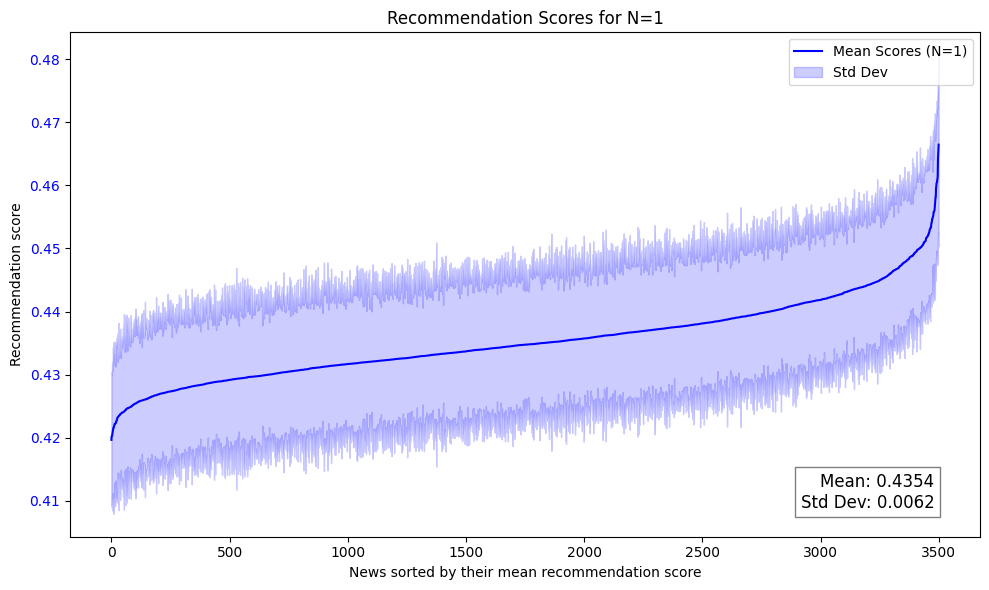

Saved plot for N=1 at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/single_mean_score_plots/scores_N1.png
N=1 Statistics:
Mean: 0.43541762232780457
Standard Deviation: 0.0062409075908362865


In [3]:
import os
import pickle
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def load_embeddings(user_path, candidate_path):
    with open(user_path, 'rb') as f:
        user_embeddings = pickle.load(f)
    
    with open(candidate_path, 'rb') as f:
        candidate_embeddings_dict = pickle.load(f)
    
    candidate_ids, candidate_embeddings = zip(*candidate_embeddings_dict.items())
    candidate_embeddings = torch.tensor(np.array(candidate_embeddings))
    
    return user_embeddings, candidate_embeddings

def sample_users(user_embeddings, sample_size=10000):
    if len(user_embeddings) > sample_size:
        sampled_indices = np.random.choice(len(user_embeddings), sample_size, replace=False)
        user_embeddings_sample = user_embeddings[sampled_indices]
    else:
        user_embeddings_sample = user_embeddings
    return user_embeddings_sample

def sample_candidates(candidate_embeddings, sample_size=3500):
    if len(candidate_embeddings) > sample_size:
        sampled_indices = np.random.choice(len(candidate_embeddings), sample_size, replace=False)
        candidate_embeddings_sample = candidate_embeddings[sampled_indices]
    else:
        candidate_embeddings_sample = candidate_embeddings
    return candidate_embeddings_sample

def adjust_embedding_dimensions(user_embeddings, candidate_embeddings):
    user_interest_dim = user_embeddings.shape[1]  # num_interest for users
    candidate_interest_dim = candidate_embeddings.shape[1]  # num_interest for candidates

    if user_interest_dim != candidate_interest_dim:
        if candidate_interest_dim < user_interest_dim:
            # Repeat candidate embeddings along the interest dimension
            candidate_embeddings = candidate_embeddings.repeat(1, user_interest_dim, 1)
        else:
            # Truncate candidate embeddings to match user embeddings' interest dimension
            candidate_embeddings = candidate_embeddings[:, :user_interest_dim, :]
    
    return candidate_embeddings

def calculate_scores(user_embeddings, candidate_embeddings, scoring_fn, batch_size=32, chunk_size=500):
    user_embeddings = torch.tensor(user_embeddings)
    candidate_embeddings = candidate_embeddings

    num_users = user_embeddings.size(0)
    num_candidates = candidate_embeddings.size(0)
    
    scores = torch.empty((num_users, num_candidates))

    for i in range(0, num_users, chunk_size):
        user_batch = user_embeddings[i:i+chunk_size]
        for j in range(0, num_candidates, chunk_size):
            candidate_batch = candidate_embeddings[j:j+chunk_size]

            user_batch_expanded = user_batch.unsqueeze(1).expand(-1, candidate_batch.size(0), -1, -1)
            candidate_batch_expanded = candidate_batch.unsqueeze(0).expand(user_batch.size(0), -1, -1, -1)

            batch_scores = scoring_fn(user_batch_expanded, candidate_batch_expanded, dim=-1).mean(dim=-1)
            scores[i:i+chunk_size, j:j+chunk_size] = batch_scores

    # Apply sigmoid to make scores positive
    scores = torch.sigmoid(scores)

    return scores

def analyze_scores(scores):
    mean_scores_per_user = scores.mean(axis=1)
    mean_scores_per_candidate = scores.mean(axis=0)
    std_scores_per_candidate = scores.std(axis=0)

    return mean_scores_per_user, mean_scores_per_candidate, std_scores_per_candidate

def calculate_overall_stats(mean_scores):
    """
    Calculate overall mean and standard deviation for the given scores.

    Args:
        mean_scores: Array of mean scores.

    Returns:
        overall_mean: Mean of the mean scores.
        overall_std: Standard deviation of the mean scores.
    """
    # Ensure mean_scores is a NumPy array
    if isinstance(mean_scores, torch.Tensor):
        mean_scores = mean_scores.numpy()
        
    overall_mean = np.mean(mean_scores)
    overall_std = np.std(mean_scores)
    
    return overall_mean, overall_std

def process_embeddings_and_plot_single(N, user_path, candidate_path, save_dir, scoring_fn=torch.nn.functional.cosine_similarity, num_users=10000, num_candidates=3500):
    """
    Processes embeddings for a single configuration and plots the scores.

    Args:
        N: The value of N being used.
        user_path: Path to the user embeddings.
        candidate_path: Path to the candidate embeddings.
        save_dir: Directory to save the plot.
        scoring_fn: Function to compute scores (default is cosine similarity).
        num_users: Number of users to sample.
        num_candidates: Number of candidates to sample.
    """
    os.makedirs(save_dir, exist_ok=True)

    # Process the configuration
    print(f'Processing {user_path} (N={N})')
    user_embeddings, candidate_embeddings = load_embeddings(user_path, candidate_path)
    candidate_embeddings = adjust_embedding_dimensions(user_embeddings, candidate_embeddings)
    
    # Sample a subset of users and candidates
    user_embeddings_sample = sample_users(user_embeddings, num_users)
    candidate_embeddings_sample = sample_candidates(candidate_embeddings, num_candidates)
    
    scores = calculate_scores(user_embeddings_sample, candidate_embeddings_sample, scoring_fn)
    mean_scores_per_user, mean_scores_per_candidate, std_scores_per_candidate = analyze_scores(scores)

    # Save the mean scores
    np.save(os.path.join(save_dir, f'mean_scores_N{N}.npy'), mean_scores_per_candidate)

    # Calculate overall statistics
    overall_mean, overall_std = calculate_overall_stats(mean_scores_per_candidate)

    # Plot the scores
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Ensure inputs are NumPy arrays
    mean_scores_per_candidate = np.array(mean_scores_per_candidate)
    std_scores_per_candidate = np.array(std_scores_per_candidate)

    # Sort the scores
    sorted_indices = np.argsort(mean_scores_per_candidate)
    sorted_mean_scores = mean_scores_per_candidate[sorted_indices]
    sorted_std_scores = std_scores_per_candidate[sorted_indices]

    # Plot
    ax.plot(sorted_mean_scores, label=f'Mean Scores (N={N})', color='blue')
    ax.fill_between(range(len(sorted_mean_scores)), sorted_mean_scores - sorted_std_scores, sorted_mean_scores + sorted_std_scores, alpha=0.2, color='blue', label='Std Dev')
    ax.set_xlabel('News sorted by their mean recommendation score')
    ax.set_ylabel('Recommendation score')
    ax.tick_params(axis='y', labelcolor='blue')
    ax.legend()

    # Annotate the plot with the overall mean and standard deviation
    textstr = f'Mean: {overall_mean:.4f}\nStd Dev: {overall_std:.4f}'
    ax.text(0.95, 0.05, textstr, transform=ax.transAxes, fontsize=12,
            verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(facecolor='white', alpha=0.5))

    plt.title(f'Recommendation Scores for N={N}')
    fig.tight_layout()

    save_path = os.path.join(save_dir, f'scores_N{N}.png')
    plt.savefig(save_path)
    plt.show()
    plt.close()
    print(f'Saved plot for N={N} at {save_path}')

    return save_path

# Example usage for N=1 with 10,000 users and 3,500 candidates
N = 1
save_dir = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/single_mean_score_plots'

process_embeddings_and_plot_single(
    N=N,
    user_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_bce_N1/user_representations.pkl',
    candidate_path='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/dev_candidate_embeddings.pkl',
    save_dir=save_dir,
    num_users=10000,
    num_candidates=3500
)

# Load saved mean scores and calculate statistics
mean_scores = np.load(os.path.join(save_dir, f'mean_scores_N{N}.npy'))

overall_mean, overall_std = calculate_overall_stats(mean_scores)
print(f'N={N} Statistics:')
print(f'Mean: {overall_mean}')
print(f'Standard Deviation: {overall_std}')


Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl (N=5)
Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl (N=10)
Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl (N=25)
Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl (N=50)


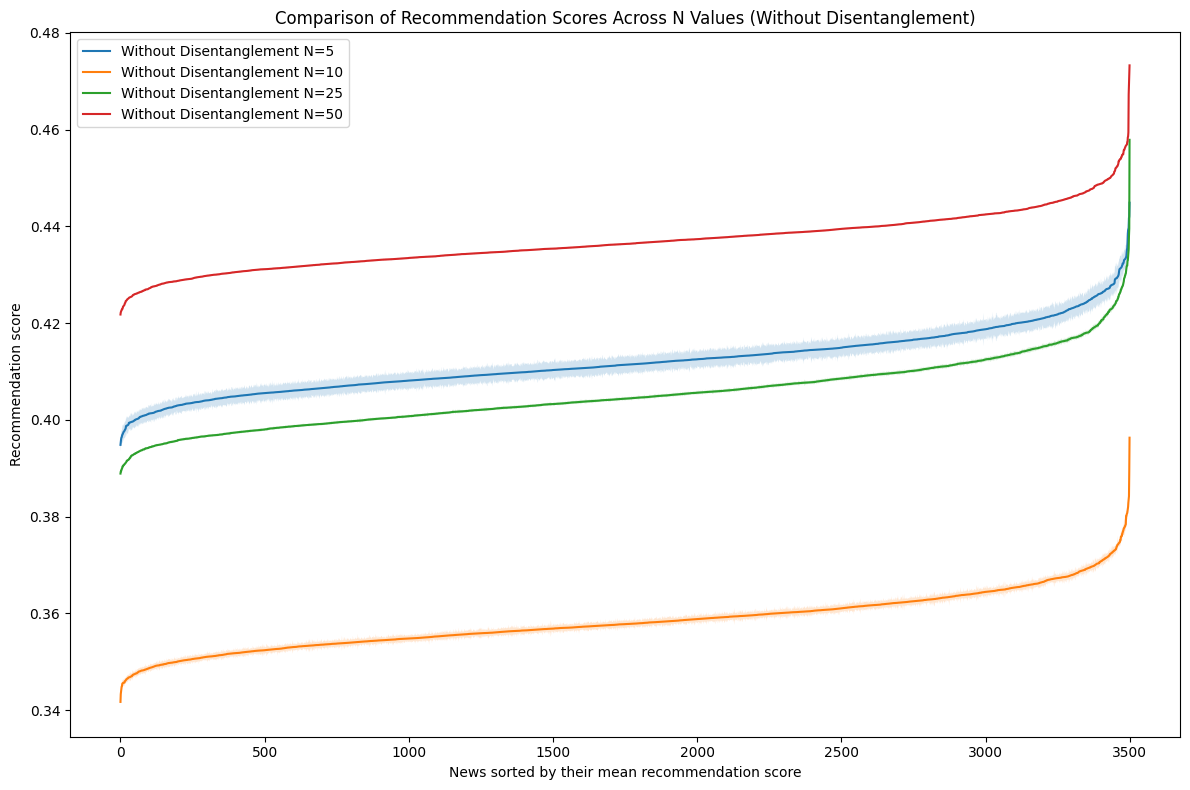

Saved combined plot at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/mean&variance_sigmoid/combined_scores_Without_Disentanglement.png
Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_dis_cos_bce_lamda_s_0.9/user_representations.pkl (N=5)
Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_dis_cos_bce_lamda_s_0.9_user_representations/user_representations.pkl (N=10)
Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_dis_cos_bce_lamda_s_0.9/user_representations.pkl (N=25)
Processing /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_dis_cos_bce_lamda_s_0.90/user_representations.pkl (N=50)


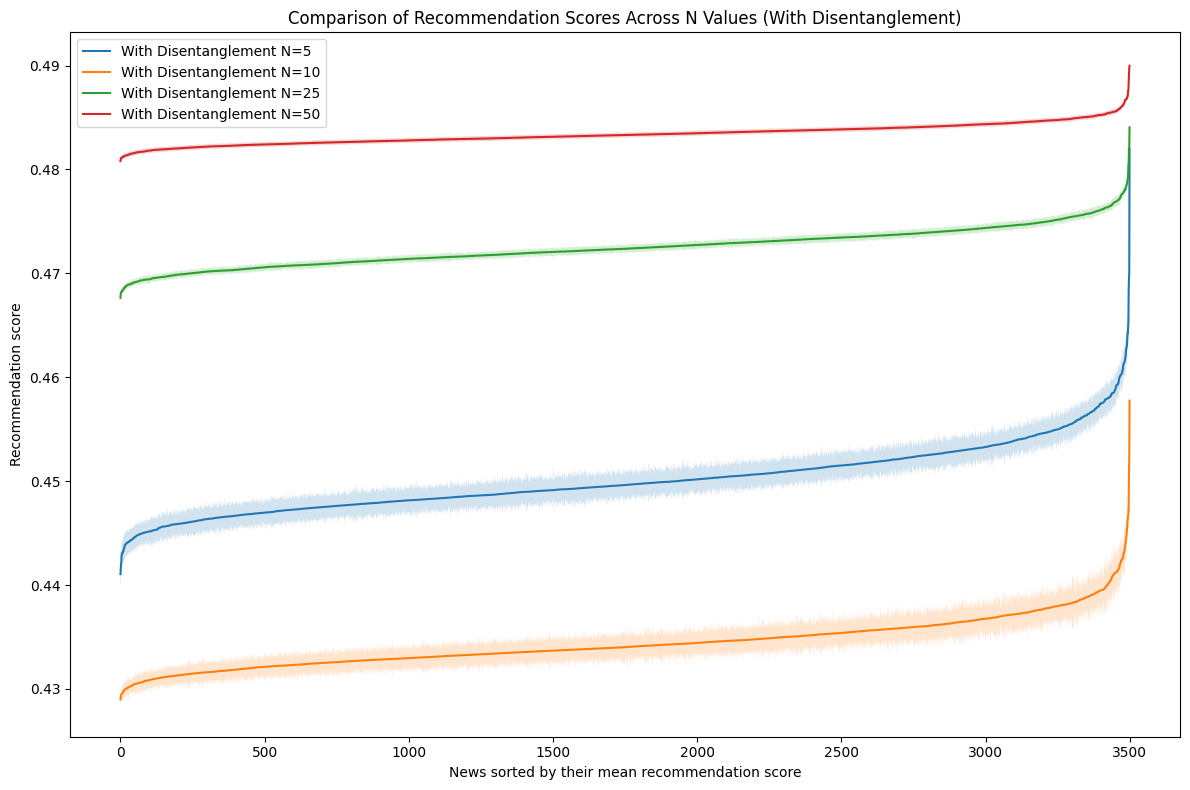

Saved combined plot at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/mean&variance_sigmoid/combined_scores_With_Disentanglement.png


'/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/mean&variance_sigmoid/combined_scores_With_Disentanglement.png'

In [4]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_combined_scores(mean_scores_dict, std_scores_dict, N_values, save_dir, label_prefix):
    """
    Plots the combined scores for different N values on the same graph.

    Args:
        mean_scores_dict: Dictionary of mean scores for different N values.
        std_scores_dict: Dictionary of standard deviation scores for different N values.
        N_values: List of N values to be plotted.
        save_dir: Directory to save the combined plot.
        label_prefix: Prefix for the labels (e.g., "Without Disentanglement", "With Disentanglement").
    """
    fig, ax = plt.subplots(figsize=(12, 8))

    for N in N_values:
        mean_scores = mean_scores_dict[N]
        std_scores = std_scores_dict[N]
        
        # Sort the scores
        sorted_indices = np.argsort(mean_scores)
        sorted_mean_scores = mean_scores[sorted_indices]
        sorted_std_scores = std_scores[sorted_indices]

        # Plot
        ax.plot(sorted_mean_scores, label=f'{label_prefix} N={N}')
        ax.fill_between(range(len(sorted_mean_scores)), sorted_mean_scores - sorted_std_scores, sorted_mean_scores + sorted_std_scores, alpha=0.2)

    ax.set_xlabel('News sorted by their mean recommendation score')
    ax.set_ylabel('Recommendation score')
    ax.legend()
    
    plt.title(f'Comparison of Recommendation Scores Across N Values ({label_prefix})')
    fig.tight_layout()

    save_path = os.path.join(save_dir, f'combined_scores_{label_prefix.replace(" ", "_")}.png')
    plt.savefig(save_path)
    plt.show()
    plt.close()
    print(f'Saved combined plot at {save_path}')

    return save_path

def process_embeddings_for_combined_plot(N_values, user_paths, candidate_path, save_dir, label_prefix, scoring_fn=torch.nn.functional.cosine_similarity):
    """
    Processes embeddings for multiple configurations and generates combined plots.

    Args:
        N_values: List of N values being used.
        user_paths: List of paths to the user embeddings corresponding to the N values.
        candidate_path: Path to the candidate embeddings.
        save_dir: Directory to save the plots.
        label_prefix: Prefix for the labels (e.g., "Without Disentanglement", "With Disentanglement").
        scoring_fn: Function to compute scores (default is cosine similarity).
    """
    mean_scores_dict = {}
    std_scores_dict = {}

    for N, user_path in zip(N_values, user_paths):
        print(f'Processing {user_path} (N={N})')
        user_embeddings, candidate_embeddings = load_embeddings(user_path, candidate_path)
        candidate_embeddings = adjust_embedding_dimensions(user_embeddings, candidate_embeddings)
        user_embeddings_sample = sample_users(user_embeddings)
        candidate_embeddings_sample = sample_candidates(candidate_embeddings)
        scores = calculate_scores(user_embeddings_sample, candidate_embeddings_sample, scoring_fn)
        mean_scores_per_user, mean_scores_per_candidate, std_scores_per_candidate = analyze_scores(scores)
        
        mean_scores_dict[N] = mean_scores_per_candidate
        std_scores_dict[N] = std_scores_per_candidate

        # Save the mean scores
        np.save(os.path.join(save_dir, f'{label_prefix}_mean_scores_N{N}.npy'), mean_scores_per_candidate)
    
    # Plot combined scores
    return plot_combined_scores(mean_scores_dict, std_scores_dict, N_values, save_dir, label_prefix)

# Paths
candidate_path = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/candidate_rep/dev_candidate_embeddings.pkl'
save_dir = '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/mean&variance_sigmoid'
N_values = [5, 10, 25, 50]

# Paths for "Without Disentanglement"
user_paths_without = [
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_user_representations/user_representations.pkl'
]

# Paths for "With Disentanglement"
user_paths_with = [
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N10_dis_cos_bce_lamda_s_0.9_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N25_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N50_dis_cos_bce_lamda_s_0.90/user_representations.pkl'
]

# Generate combined plot for "Without Disentanglement"
process_embeddings_for_combined_plot(
    N_values=N_values,
    user_paths=user_paths_without,
    candidate_path=candidate_path,
    save_dir=save_dir,
    label_prefix="Without Disentanglement"
)

# Generate combined plot for "With Disentanglement"
process_embeddings_for_combined_plot(
    N_values=N_values,
    user_paths=user_paths_with,
    candidate_path=candidate_path,
    save_dir=save_dir,
    label_prefix="With Disentanglement"
)
